# DSN Mart Sales Prediction — Reproducible Solution

This is the consolidated submission notebook for the **DSN-only AutoGluon ensemble** that scored
**1072.91384 public RMSE**. It starts from the raw competition files and contains the complete
workflow: data checks, focused EDA, deterministic cleaning, feature engineering, product-coverage-
matched validation, GPU AutoML training, full-data refitting, and guarded submission export.

**Scope and integrity**

- Training labels come only from `train.csv`.
- `test.csv` is used only for its features and final predictions.
- The unique row ID is excluded from modelling.
- Missing values are treated as unknown—not as zero—and explicit missingness flags are added.
- The public score is historical evidence, not a guarantee of the private-leaderboard score.

The exact validated run was `20260914T120605Z` with AutoGluon 1.6.1, a Tesla T4, the `extreme`
preset, and a 600-second budget for each outer validation run and the final refit.


## How to run in Google Colab

1. Select a **GPU runtime**.
2. Ensure the project is at `/content/drive/MyDrive/DSN_HACKATHON` and the three CSV files are
   inside `data/raw/` (the notebook also checks `data/` as a fallback).
3. Run the cells from top to bottom.
4. Keep `REUSE_VALIDATED_ARTIFACTS = True` to reproduce the already-validated run when its saved
   artifacts are present. Set it to `False` only when intentionally retraining the whole experiment.
5. Upload only the CSV printed by the final cell.

A fresh end-to-end GPU run trains three outer models plus one full-data model and can take roughly
40–60 minutes. Loading the validated artifacts is much faster.


In [1]:
# 0 — Install the exact modelling stack used by the scored run.
# Run once in a fresh Colab runtime. Restart only if Colab explicitly asks.
import subprocess
import sys

packages = [
    "autogluon.tabular[tabarena]==1.6.1",
    "seaborn>=0.13,<0.14",
]
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-U", *packages]
)
print("Installation complete.")


Installation complete.


In [2]:
# 1 — Imports, Colab Drive, paths, and run configuration
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
import hashlib
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from autogluon.tabular import TabularPredictor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Drive mount skipped (normal outside Colab): {exc}")

root_candidates = [
    Path("/content/drive/MyDrive/DSN_HACKATHON"),
    Path.cwd(),
    Path.cwd().parent,
]
ROOT = next(
    (path for path in root_candidates if (path / "data").exists()),
    root_candidates[0],
)
RAW = ROOT / "data" / "raw"
if not (RAW / "train.csv").exists():
    RAW = ROOT / "data"

TRAIN_PATH = RAW / "train.csv"
TEST_PATH = RAW / "test.csv"
SAMPLE_PATH = RAW / "sample_submission.csv"
ID_COL = "id"
TARGET = "total_sales"

# Reuse gives exact auditability; turning it off deliberately retrains.
REUSE_VALIDATED_ARTIFACTS = True
RUN_OUTER_VALIDATION = True
RUN_FULL_REFIT = True
EXPORT_SUBMISSION = True
OUTER_SEEDS = [2026, 123, 31415]
AUTOGLUON_PRESET = "extreme"
TIME_LIMIT_PER_OUTER = 600
TIME_LIMIT_FULL = 600

VALIDATED_RUN_ID = "20260914T120605Z"
VALIDATED_RUN = ROOT / "artifacts" / "automl_foundation" / VALIDATED_RUN_ID
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUT = ROOT / "artifacts" / "dsn_only_submission" / RUN_ID
SUBMISSIONS = ROOT / "submissions"
OUT.mkdir(parents=True, exist_ok=True)
SUBMISSIONS.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Artifact directory:", OUT)
print("AutoGluon version:", version("autogluon.tabular"))
print("Validated artifacts available:", VALIDATED_RUN.exists())


Mounted at /content/drive
Project root: /content/drive/MyDrive/DSN_HACKATHON
Artifact directory: /content/drive/MyDrive/DSN_HACKATHON/artifacts/dsn_only_submission/20260925T211256Z
AutoGluon version: 1.6.1
Validated artifacts available: True


## 2. Load and validate the competition data

Reproducibility begins with the files, not the model. We verify the expected schema, row counts,
train/test feature alignment, unique IDs, and file hashes. If any of these checks fails, stop rather
than create a submission from the wrong dataset or row order.


In [3]:
# 2 — Load raw files and create a data manifest
for required_path in [TRAIN_PATH, TEST_PATH, SAMPLE_PATH]:
    assert required_path.exists(), f"Missing required file: {required_path}"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

assert train.shape == (6818, 13), f"Unexpected train shape: {train.shape}"
assert test.shape == (1705, 12), f"Unexpected test shape: {test.shape}"
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=[TARGET]).columns.tolist() == test.columns.tolist()
assert sample_submission.columns.tolist() == [ID_COL, TARGET]
assert sample_submission[ID_COL].equals(test[ID_COL])
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert train[ID_COL].notna().all() and test[ID_COL].notna().all()
assert np.isfinite(train[TARGET].to_numpy(float)).all()

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

data_manifest = {
    "train_sha256": sha256_file(TRAIN_PATH),
    "test_sha256": sha256_file(TEST_PATH),
    "sample_submission_sha256": sha256_file(SAMPLE_PATH),
    "train_shape": list(train.shape),
    "test_shape": list(test.shape),
}
(OUT / "data_manifest.json").write_text(
    json.dumps(data_manifest, indent=2), encoding="utf-8"
)

display(train.head())
print("Train:", train.shape, "| Test:", test.shape)
print("Data hashes saved to:", OUT / "data_manifest.json")


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


Train: (6818, 13) | Test: (1705, 12)
Data hashes saved to: /content/drive/MyDrive/DSN_HACKATHON/artifacts/dsn_only_submission/20260925T211256Z/data_manifest.json


## 3. Focused EDA and the decisions it changed

The EDA is deliberately tied to modelling decisions:

- `product_weight_kg` and `store_size` contain missing values. A missing value means **unknown**, not
  zero. AutoGluon keeps the missing value while we add a flag that lets models learn whether missingness
  itself matters.
- `product_category` contains inconsistent capitalization and `fat_content` contains label aliases;
  both are normalized identically in train and test.
- Price is strongly tied to sales scale, so the model receives both raw price and `log1p(price)`.
- Shelf visibility is skewed and contains exact zeros. We retain the raw value, add a zero flag, and
  add `log1p(visibility)`.
- Products and stores repeat. Approximately **99.65% of test rows use a product observed in train**,
  so validation should reproduce that product-availability pattern rather than rely on one arbitrary
  random split.
- The target is right-skewed and RMSE penalizes large misses heavily. Ensembles help stabilize the
  expensive tail without changing the competition target.


In [4]:
# 3.1 — Missingness, cardinality, and train/test product coverage
profile = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "train_missing": train.isna().sum(),
    "train_missing_pct": train.isna().mean().mul(100).round(2),
    "test_missing": test.isna().sum().reindex(train.columns),
    "train_unique": train.nunique(dropna=False),
    "test_unique": test.nunique(dropna=False).reindex(train.columns),
})
display(profile)

train_products = set(train["product_code"].dropna().astype(str))
test_product_seen = test["product_code"].astype(str).isin(train_products)
product_coverage = pd.DataFrame([{
    "train_rows": len(train),
    "test_rows": len(test),
    "train_unique_products": train["product_code"].nunique(),
    "test_unique_products": test["product_code"].nunique(),
    "test_rows_with_seen_product": int(test_product_seen.sum()),
    "test_rows_with_unseen_product": int((~test_product_seen).sum()),
    "test_product_seen_rate": float(test_product_seen.mean()),
    "train_unique_stores": train["store_code"].nunique(),
    "test_unique_stores": test["store_code"].nunique(),
}])
display(product_coverage)

target_summary = train[TARGET].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
display(target_summary.to_frame("total_sales"))


,dtype,train_missing,train_missing_pct,test_missing,train_unique,test_unique
id,object,0,0.00,0.0,6818,1705.0
product_code,object,0,0.00,0.0,1555,1082.0
product_weight_kg,float64,1225,17.97,306.0,4676,1330.0
fat_content,object,0,0.00,0.0,2,2.0
shelf_visibility,float64,0,0.00,0.0,1732,984.0
product_category,object,0,0.00,0.0,48,48.0
product_price,float64,0,0.00,0.0,5818,1650.0
store_code,object,0,0.00,0.0,10,10.0
store_age_years,int64,0,0.00,0.0,9,9.0
store_size,object,1919,28.15,491.0,4,4.0


,train_rows,test_rows,train_unique_products,test_unique_products,test_rows_with_seen_product,test_rows_with_unseen_product,test_product_seen_rate,train_unique_stores,test_unique_stores
0,6818,1705,1555,1082,1699,6,0.996481,10,10


,total_sales
count,6818.000000
mean,2174.756574
std,1697.894956
min,32.700000
1%,81.201700
5%,188.119000
50%,1790.890000
95%,5557.191000
99%,7261.389300
max,12996.820000


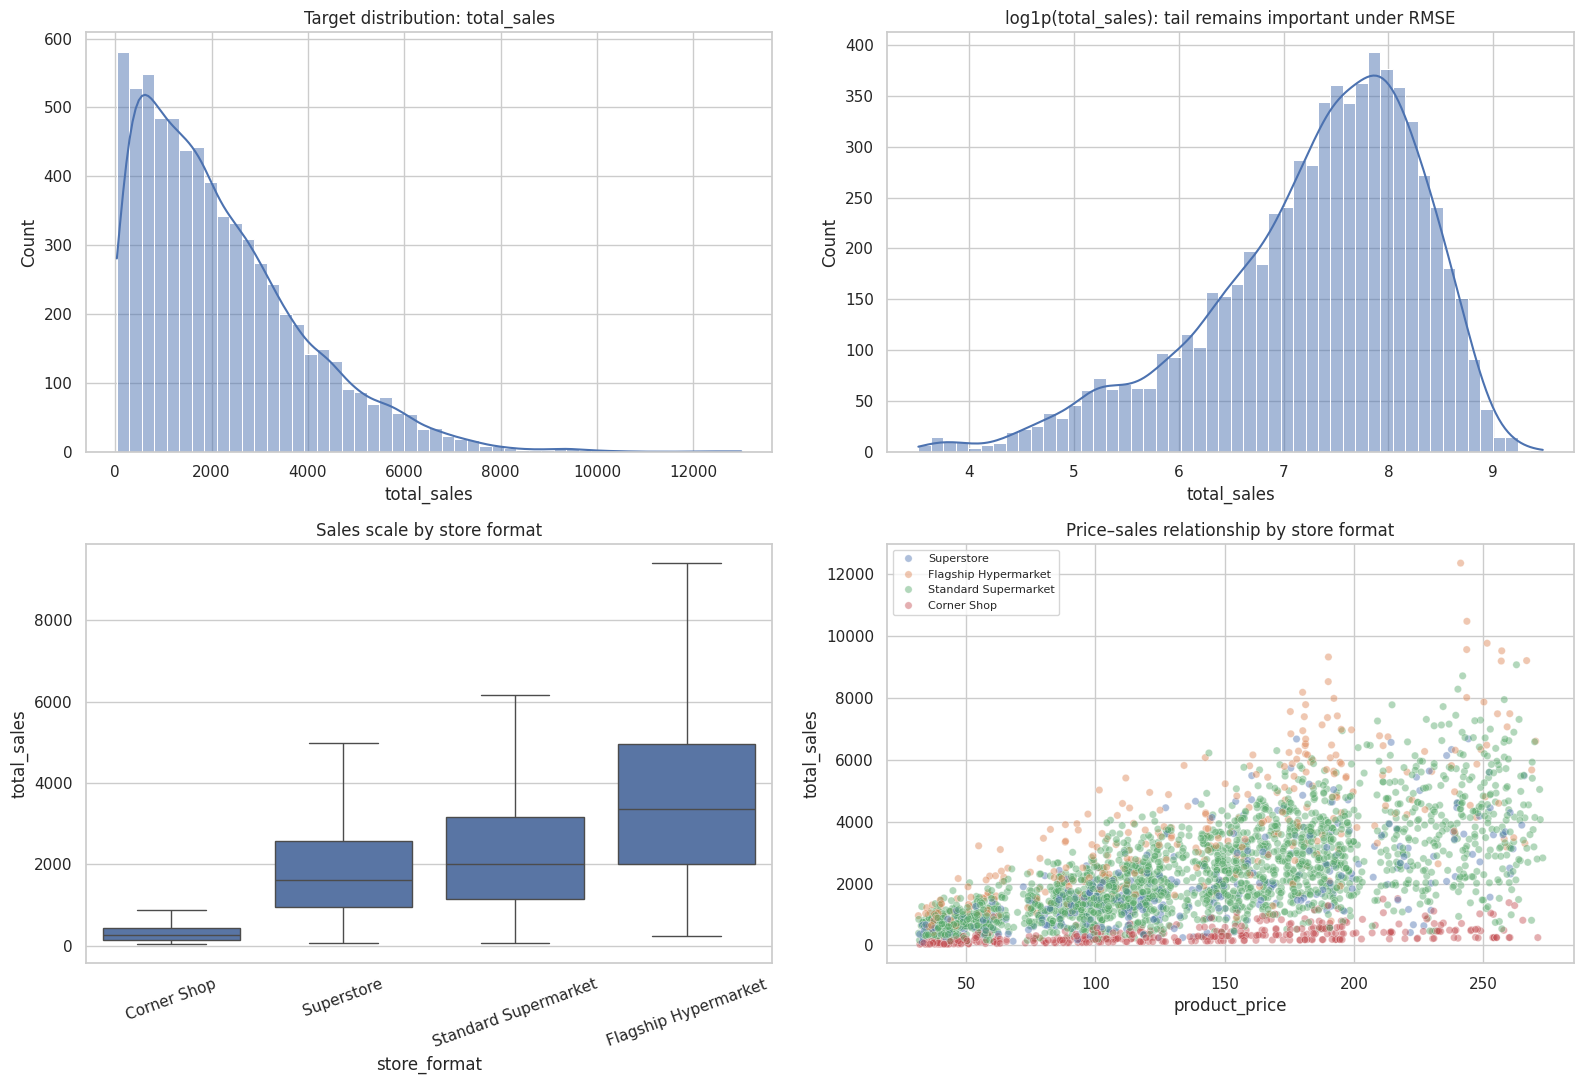

In [5]:
# 3.2 — Compact visuals: target shape, store-format scale, and price relationship
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(train[TARGET], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Target distribution: total_sales")

sns.histplot(np.log1p(train[TARGET]), bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("log1p(total_sales): tail remains important under RMSE")

order = (
    train.groupby("store_format")[TARGET]
    .median()
    .sort_values()
    .index
)
sns.boxplot(
    data=train,
    x="store_format",
    y=TARGET,
    order=order,
    showfliers=False,
    ax=axes[1, 0],
)
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].set_title("Sales scale by store format")

plot_sample = train.sample(min(3000, len(train)), random_state=2026)
sns.scatterplot(
    data=plot_sample,
    x="product_price",
    y=TARGET,
    hue="store_format",
    alpha=0.45,
    s=28,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Price–sales relationship by store format")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. Deterministic cleaning and feature engineering

Every transformation below is target-free and applied by the same function to train, validation, and
test. This prevents train/test drift and makes the final refit identical to the validation recipe.

We intentionally avoid aggressive manual target encoding here. Earlier experiments showed that such
encodings are easy to leak across folds and did not deliver a repeatable gain once evaluated honestly.
The final model instead lets AutoGluon's diverse tabular ensemble learn nonlinear product, store, price,
and category interactions.


In [6]:
# 4 — Exact 16-feature view used by the 1072.91384 run
def make_features(frame):
    out = frame.drop(columns=[ID_COL, TARGET], errors="ignore").copy()

    # Missing is information; it is not a physical value of zero.
    out["product_weight_missing"] = out["product_weight_kg"].isna().astype("int8")
    out["store_size_missing"] = out["store_size"].isna().astype("int8")
    out["is_zero_visibility"] = out["shelf_visibility"].eq(0).astype("int8")

    out["product_category"] = (
        out["product_category"]
        .astype("string")
        .str.strip()
        .str.lower()
        .str.title()
    )
    out["fat_content"] = (
        out["fat_content"]
        .astype("string")
        .str.strip()
        .replace({"LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"})
    )

    for column in [
        "product_code",
        "store_code",
        "store_size",
        "store_location_tier",
        "store_format",
    ]:
        out[column] = out[column].astype("string").str.strip().fillna("Unknown")

    out["log_product_price"] = np.log1p(out["product_price"])
    out["log_shelf_visibility"] = np.log1p(out["shelf_visibility"])
    return out

X = make_features(train)
X_test = make_features(test)
y = train[TARGET].to_numpy(float)

assert ID_COL not in X.columns and TARGET not in X.columns
assert X.columns.tolist() == X_test.columns.tolist()
assert X.shape == (6818, 16) and X_test.shape == (1705, 16)
assert np.isfinite(y).all()

feature_inventory = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).to_numpy(),
    "train_missing": X.isna().sum().to_numpy(),
    "test_missing": X_test.isna().sum().to_numpy(),
    "unique_train": X.nunique(dropna=False).to_numpy(),
})
display(feature_inventory)
print("Feature count:", X.shape[1])


,feature,dtype,train_missing,test_missing,unique_train
0,product_code,string,0,0,1555
1,product_weight_kg,float64,1225,306,4676
2,fat_content,string,0,0,2
3,shelf_visibility,float64,0,0,1732
4,product_category,string,0,0,16
5,product_price,float64,0,0,5818
6,store_code,string,0,0,10
7,store_age_years,int64,0,0,9
8,store_size,string,0,0,4
9,store_location_tier,string,0,0,3


Feature count: 16


## 5. Validation design: match the actual prediction problem

A single random split was too noisy for a leaderboard decision. We therefore use three independent
80/20 outer holdouts. They preserve target quantiles and match the **feature-only** product-availability
rate observed in test:

- A small quota of singleton products is held out completely to represent unseen test products.
- For every repeated product, at least one row remains in outer training.
- Test targets are never accessed.
- The outer validation frame is never supplied to `predictor.fit`.

This is a repeated matched-holdout protocol, not ordinary shuffled K-fold CV. Its purpose is to estimate
performance under the same seen/unseen-product mixture the final test set presents.


In [7]:
# 5 — Build the exact product-coverage-matched outer holdouts
products = train["product_code"].fillna("MISSING_PRODUCT").astype(str).to_numpy()
product_counts = pd.Series(products).value_counts()
row_product_count = pd.Series(products).map(product_counts).to_numpy(int)
target_strata = np.asarray(
    pd.qcut(y, q=10, labels=False, duplicates="drop"), dtype=int
)
strata_counts = pd.Series(target_strata).value_counts().sort_index()
strata_values = strata_counts.index.to_list()
n_rows = len(train)
n_valid = int(round(0.20 * n_rows))
test_product_seen_rate = float(
    test["product_code"].isin(train["product_code"]).mean()
)
target_unseen_rows = int(round((1.0 - test_product_seen_rate) * n_valid))
singleton_indices = np.flatnonzero(row_product_count == 1)

def make_quotas(total):
    raw = strata_counts / strata_counts.sum() * total
    quotas = np.floor(raw).astype(int)
    remainder = int(total - quotas.sum())
    if remainder:
        fractions = (raw - quotas).sort_values(ascending=False, kind="stable")
        for stratum in fractions.index[:remainder]:
            quotas.loc[stratum] += 1
    return quotas.to_dict()

def choose_matched_validation(seed):
    rng = np.random.default_rng(seed)
    target_quota = make_quotas(n_valid)
    unseen_quota = make_quotas(target_unseen_rows)
    selected = []
    selected_set = set()
    selected_per_stratum = {stratum: 0 for stratum in strata_values}

    # Completely unseen products are represented by singleton rows.
    for stratum in strata_values:
        candidates = singleton_indices[
            target_strata[singleton_indices] == stratum
        ]
        take = min(int(unseen_quota[stratum]), len(candidates))
        if take:
            chosen = rng.choice(candidates, size=take, replace=False)
            selected.extend(chosen.tolist())
            selected_set.update(chosen.tolist())
            selected_per_stratum[stratum] += take

    singleton_needed = target_unseen_rows - len(selected)
    if singleton_needed:
        remaining = np.asarray([
            index for index in singleton_indices if index not in selected_set
        ])
        extra = rng.choice(remaining, size=singleton_needed, replace=False)
        selected.extend(extra.tolist())
        selected_set.update(extra.tolist())
        for index in extra:
            selected_per_stratum[target_strata[index]] += 1

    # Repeated products can contribute rows but must retain one training row.
    remaining_capacity = {
        product: int(count - 1)
        for product, count in product_counts.items()
        if count >= 2
    }

    def take_candidates(candidates, required):
        chosen = []
        for index in rng.permutation(candidates):
            if index in selected_set:
                continue
            product = products[index]
            if remaining_capacity.get(product, 0) <= 0:
                continue
            chosen.append(int(index))
            selected_set.add(int(index))
            remaining_capacity[product] -= 1
            if len(chosen) == required:
                break
        return chosen

    for stratum in strata_values:
        needed = max(
            0,
            int(target_quota[stratum] - selected_per_stratum[stratum]),
        )
        if needed:
            candidates = np.flatnonzero(
                (target_strata == stratum) & (row_product_count >= 2)
            )
            chosen = take_candidates(candidates, needed)
            selected.extend(chosen)
            selected_per_stratum[stratum] += len(chosen)

    remainder_needed = n_valid - len(selected)
    if remainder_needed:
        chosen = take_candidates(
            np.flatnonzero(row_product_count >= 2), remainder_needed
        )
        selected.extend(chosen)

    valid_idx = np.sort(np.asarray(selected, dtype=int))
    fit_idx = np.setdiff1d(
        np.arange(n_rows, dtype=int), valid_idx, assume_unique=True
    )
    fit_products = set(products[fit_idx])
    known_rate = float(pd.Series(products[valid_idx]).isin(fit_products).mean())

    assert len(fit_idx) == 5454 and len(valid_idx) == 1364
    assert len(np.intersect1d(fit_idx, valid_idx)) == 0
    assert abs(known_rate - test_product_seen_rate) < 0.001
    return fit_idx, valid_idx, known_rate

OUTER_SPLITS = {}
split_rows = []
split_dir = OUT / "matched_splits"
split_dir.mkdir(parents=True, exist_ok=True)

for seed in OUTER_SEEDS:
    fit_idx, valid_idx, known_rate = choose_matched_validation(seed)
    OUTER_SPLITS[seed] = {"fit_idx": fit_idx, "valid_idx": valid_idx}
    np.savez_compressed(
        split_dir / f"outer_matched_split_seed_{seed}.npz",
        fit_idx=fit_idx,
        valid_idx=valid_idx,
    )
    split_rows.append({
        "seed": seed,
        "train_rows": len(fit_idx),
        "validation_rows": len(valid_idx),
        "validation_product_seen_rate": known_rate,
        "test_product_seen_rate": test_product_seen_rate,
        "validation_target_mean": float(y[valid_idx].mean()),
        "validation_target_std": float(y[valid_idx].std()),
    })

split_summary = pd.DataFrame(split_rows)
split_summary.to_csv(OUT / "matched_split_summary.csv", index=False)
display(split_summary)


,seed,train_rows,validation_rows,validation_product_seen_rate,test_product_seen_rate,validation_target_mean,validation_target_std
0,2026,5454,1364,0.996334,0.996481,2176.007845,1702.998065
1,123,5454,1364,0.996334,0.996481,2176.022801,1721.527160
2,31415,5454,1364,0.996334,0.996481,2188.137148,1729.072034


## 6. Model: AutoGluon extreme-quality ensemble

AutoGluon's `extreme` preset is useful here because the data is small, heterogeneous, and strongly
nonlinear. It trains several complementary tabular learners and combines them with a weighted ensemble.
In the validated run, the ensemble included modern tabular foundation models and boosted-tree components;
the best final model was `WeightedEnsemble_L2`.

The gate compares the model with the previously locked CatBoost quantity baseline on the **same outer
rows**. A candidate proceeds only when every repeat improves and mean gain exceeds 0.50 RMSE. The stored
reference baseline is used only for auditing this already-completed experiment; it is not trained on or
inferred from test labels.


In [8]:
# 6 — Three honest outer evaluations; load exact artifacts or retrain
BASELINE_RMSE = {
    2026: 1061.094191,
    123: 1069.186620,
    31415: 1090.864303,
}
RECORDED_AUTOML_RMSE = {
    2026: 1058.825035,
    123: 1060.783110,
    31415: 1088.838590,
}

def rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.sqrt(np.mean(np.square(actual - predicted))))

def gpu_is_visible():
    return os.system("nvidia-smi > /dev/null 2>&1") == 0

assert RUN_OUTER_VALIDATION, "Outer validation is required before a new refit."
outer_rows = []

for seed in OUTER_SEEDS:
    print(f"\nOuter holdout seed {seed}")
    fit_idx = OUTER_SPLITS[seed]["fit_idx"]
    valid_idx = OUTER_SPLITS[seed]["valid_idx"]
    saved_prediction_path = VALIDATED_RUN / f"predictions_seed_{seed}.csv"

    if REUSE_VALIDATED_ARTIFACTS and saved_prediction_path.exists():
        saved = pd.read_csv(saved_prediction_path)
        assert saved.columns.tolist() == ["row_index", "truth", "prediction"]
        assert np.array_equal(saved["row_index"].to_numpy(int), valid_idx)
        assert np.allclose(saved["truth"].to_numpy(float), y[valid_idx])
        prediction = saved["prediction"].to_numpy(float)
        source = "validated prediction artifact"
        best_model = "recorded AutoGluon ensemble"
    else:
        assert gpu_is_visible(), "Switch Colab to a GPU runtime before training."
        fold_train = make_features(train.iloc[fit_idx].reset_index(drop=True))
        fold_valid = make_features(train.iloc[valid_idx].reset_index(drop=True))
        fold_train[TARGET] = y[fit_idx]

        model_dir = OUT / f"autogluon_extreme_seed_{seed}"
        started = time.time()
        predictor = TabularPredictor(
            label=TARGET,
            problem_type="regression",
            eval_metric="root_mean_squared_error",
            path=str(model_dir),
            verbosity=2,
            log_to_file=True,
        )
        predictor.fit(
            train_data=fold_train,
            presets=AUTOGLUON_PRESET,
            time_limit=TIME_LIMIT_PER_OUTER,
            num_gpus=1,
            num_cpus=max(1, os.cpu_count() or 1),
            dynamic_stacking=False,
        )
        prediction = np.maximum(
            0.0, predictor.predict(fold_valid).to_numpy(float)
        )
        source = f"fresh fit ({time.time() - started:.1f}s)"
        best_model = predictor.model_best
        predictor.leaderboard(
            fold_valid.assign(**{TARGET: y[valid_idx]}), silent=True
        ).to_csv(OUT / f"leaderboard_seed_{seed}.csv", index=False)
        pd.DataFrame({
            "row_index": valid_idx,
            "truth": y[valid_idx],
            "prediction": prediction,
        }).to_csv(OUT / f"predictions_seed_{seed}.csv", index=False)

    fold_rmse = rmse(y[valid_idx], prediction)
    if source == "validated prediction artifact":
        assert abs(fold_rmse - RECORDED_AUTOML_RMSE[seed]) < 1e-4

    gain = BASELINE_RMSE[seed] - fold_rmse
    outer_rows.append({
        "seed": seed,
        "catboost_reference_rmse": BASELINE_RMSE[seed],
        "autogluon_rmse": fold_rmse,
        "gain": gain,
        "best_model": best_model,
        "source": source,
        "prediction_std": float(np.std(prediction)),
    })
    print(f"RMSE={fold_rmse:.6f} | gain={gain:+.6f} | {source}")

outer_results = pd.DataFrame(outer_rows)
mean_gain = float(outer_results["gain"].mean())
minimum_gain = float(outer_results["gain"].min())
validation_passed = bool(mean_gain > 0.50 and minimum_gain > 0.00)

validation_summary = pd.DataFrame([{
    "mean_autogluon_rmse": float(outer_results["autogluon_rmse"].mean()),
    "mean_gain_vs_catboost": mean_gain,
    "minimum_repeat_gain": minimum_gain,
    "all_repeats_positive": bool((outer_results["gain"] > 0).all()),
    "passed_gate": validation_passed,
}])
outer_results.to_csv(OUT / "outer_results.csv", index=False)
validation_summary.to_csv(OUT / "validation_summary.csv", index=False)
display(outer_results)
display(validation_summary)
assert validation_passed, "Validation gate failed; do not refit or export."



Outer holdout seed 2026
RMSE=1058.825035 | gain=+2.269156 | validated prediction artifact

Outer holdout seed 123
RMSE=1060.783110 | gain=+8.403510 | validated prediction artifact

Outer holdout seed 31415
RMSE=1088.838590 | gain=+2.025713 | validated prediction artifact


,seed,catboost_reference_rmse,autogluon_rmse,gain,best_model,source,prediction_std
0,2026,1061.094191,1058.825035,2.269156,recorded AutoGluon ensemble,validated prediction artifact,1321.762602
1,123,1069.186620,1060.783110,8.403510,recorded AutoGluon ensemble,validated prediction artifact,1343.198516
2,31415,1090.864303,1088.838590,2.025713,recorded AutoGluon ensemble,validated prediction artifact,1337.675404


,mean_autogluon_rmse,mean_gain_vs_catboost,minimum_repeat_gain,all_repeats_positive,passed_gate
0,1069.482245,4.232793,2.025713,True,True


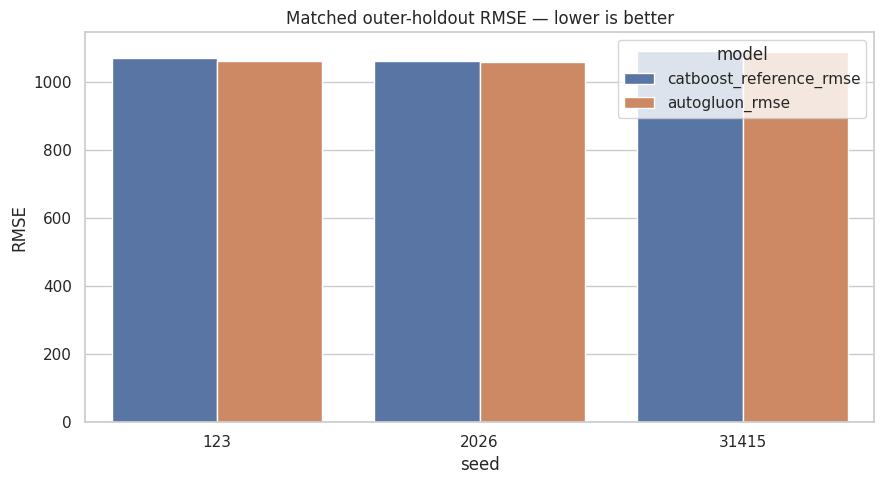

In [9]:
# 6.1 — Visualize repeat stability instead of relying on one average
plot_results = outer_results.melt(
    id_vars="seed",
    value_vars=["catboost_reference_rmse", "autogluon_rmse"],
    var_name="model",
    value_name="rmse",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_results, x="seed", y="rmse", hue="model")
plt.title("Matched outer-holdout RMSE — lower is better")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


## 7. What validation established

The historical matched-holdout results were:

| Seed | AutoGluon RMSE | CatBoost reference | Gain |
|---:|---:|---:|---:|
| 2026 | 1058.825035 | 1061.094191 | +2.269156 |
| 123 | 1060.783110 | 1069.186620 | +8.403510 |
| 31415 | 1088.838590 | 1090.864303 | +2.025713 |

Mean gain was **+4.232793 RMSE**, and all three repeats improved. This repeat stability justified a
full-data refit. It also taught us that complicated post-hoc residual corrections, arbitrary prediction
caps, and weakly validated blends were not needed: most failed to improve consistently across repeats.
The final solution therefore keeps the preprocessing transparent and lets the diversified ensemble do
the modelling.


## 8. Full-data refit

After the validation gate passes, the same feature function and AutoGluon configuration are fitted on
every labelled row. No validation labels or leaderboard score are used to alter test predictions.

When the exact saved predictor exists, loading it is the strongest reproducibility path: it recreates
the model that produced the scored submission. If it is absent, this cell performs a fresh refit with
the same preset and budget. Because the training is time-budgeted and hardware-dependent, a fresh fit
may select a slightly different ensemble even with the same recipe.


In [10]:
# 8 — Load the exact validated full model or refit it on all labelled rows
assert RUN_FULL_REFIT, "Set RUN_FULL_REFIT=True to create final predictions."
assert validation_passed, "The repeated outer-validation gate must pass first."

full_train = make_features(train)
full_train[TARGET] = y
full_test = make_features(test)
validated_model_dir = VALIDATED_RUN / "autogluon_extreme_full_data"

if (
    REUSE_VALIDATED_ARTIFACTS
    and (validated_model_dir / "predictor.pkl").exists()
):
    predictor_full = TabularPredictor.load(str(validated_model_dir))
    full_model_source = f"validated model artifact: {validated_model_dir}"
else:
    assert gpu_is_visible(), "Switch Colab to a GPU runtime before the full refit."
    model_dir_full = OUT / "autogluon_extreme_full_data"
    predictor_full = TabularPredictor(
        label=TARGET,
        problem_type="regression",
        eval_metric="root_mean_squared_error",
        path=str(model_dir_full),
        verbosity=2,
        log_to_file=True,
    )
    predictor_full.fit(
        train_data=full_train,
        presets=AUTOGLUON_PRESET,
        time_limit=TIME_LIMIT_FULL,
        num_gpus=1,
        num_cpus=max(1, os.cpu_count() or 1),
        dynamic_stacking=False,
    )
    full_model_source = f"fresh full-data fit: {model_dir_full}"

prediction_full = np.maximum(
    0.0, predictor_full.predict(full_test).to_numpy(float)
)
assert len(prediction_full) == len(test)
assert np.isfinite(prediction_full).all()

full_diagnostics = pd.DataFrame([{
    "model_source": full_model_source,
    "best_model": predictor_full.model_best,
    "prediction_mean": float(prediction_full.mean()),
    "prediction_std": float(prediction_full.std()),
    "prediction_min": float(prediction_full.min()),
    "prediction_p05": float(np.quantile(prediction_full, 0.05)),
    "prediction_p50": float(np.quantile(prediction_full, 0.50)),
    "prediction_p95": float(np.quantile(prediction_full, 0.95)),
    "prediction_max": float(prediction_full.max()),
}])
full_diagnostics.to_csv(OUT / "full_refit_diagnostics.csv", index=False)
display(full_diagnostics)

# Fingerprint of the exact public-scored run; useful as a warning, not a tuning target.
recorded_fingerprint = {
    "mean": 2203.775617,
    "std": 1314.716259,
    "p05": 328.713232,
    "p50": 2071.285156,
    "p95": 4300.485547,
}
current_fingerprint = {
    "mean": float(prediction_full.mean()),
    "std": float(prediction_full.std()),
    "p05": float(np.quantile(prediction_full, 0.05)),
    "p50": float(np.quantile(prediction_full, 0.50)),
    "p95": float(np.quantile(prediction_full, 0.95)),
}
fingerprint_comparison = pd.DataFrame({
    "recorded_1072_91384_run": recorded_fingerprint,
    "current_run": current_fingerprint,
})
fingerprint_comparison["absolute_difference"] = (
    fingerprint_comparison["current_run"]
    - fingerprint_comparison["recorded_1072_91384_run"]
).abs()
display(fingerprint_comparison)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


nori.pt: reconstructing file:   0%|          |  0.00B /  117MB            

nori.pt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/534 [00:00<?, ?B/s]

,model_source,best_model,prediction_mean,prediction_std,prediction_min,prediction_p05,prediction_p50,prediction_p95,prediction_max
0,validated model artifact: /content/drive/MyDri...,WeightedEnsemble_L2,2203.775617,1314.716259,156.723038,328.713232,2071.285156,4300.485547,6333.056152


,recorded_1072_91384_run,current_run,absolute_difference
mean,2203.775617,2203.775617,7.955077e-08
std,1314.716259,1314.716259,1.520061e-08
p05,328.713232,328.713232,4.218750e-07
p50,2071.285156,2071.285156,2.500001e-07
p95,4300.485547,4300.485547,1.250000e-07


## 9. Guarded submission export

The most damaging submission bugs are often mundane: wrong row order, wrong ID column, missing values,
extra columns, or accidentally exporting validation predictions. The next cell checks every one of those
conditions and writes a two-column CSV in the exact sample-submission order.


In [11]:
# 9 — Final submission contract and audit manifest
assert EXPORT_SUBMISSION, "Set EXPORT_SUBMISSION=True only after reviewing diagnostics."
assert validation_passed
assert sample_submission[ID_COL].equals(test[ID_COL])

submission = sample_submission.copy()
submission[TARGET] = prediction_full

assert submission.columns.tolist() == [ID_COL, TARGET]
assert submission.shape == (len(test), 2)
assert submission[ID_COL].equals(test[ID_COL])
assert submission[ID_COL].is_unique and submission[ID_COL].notna().all()
assert np.isfinite(submission[TARGET].to_numpy(float)).all()
assert (submission[TARGET] >= 0).all()

submission_path = (
    SUBMISSIONS
    / f"submission_dsn_only_autogluon_extreme_1072_91384_{RUN_ID}.csv"
)
submission.to_csv(submission_path, index=False)

run_manifest = {
    "run_id": RUN_ID,
    "historical_public_rmse": 1072.91384,
    "scope": "DSN competition data only",
    "model_source": full_model_source,
    "autogluon_version": version("autogluon.tabular"),
    "preset": AUTOGLUON_PRESET,
    "time_limit_per_outer_seconds": TIME_LIMIT_PER_OUTER,
    "time_limit_full_seconds": TIME_LIMIT_FULL,
    "outer_seeds": OUTER_SEEDS,
    "feature_count": int(X.shape[1]),
    "id_used_as_feature": False,
    "validation_passed": bool(validation_passed),
    "mean_outer_gain_vs_catboost": float(mean_gain),
    "minimum_outer_gain_vs_catboost": float(minimum_gain),
    "data_manifest": data_manifest,
    "submission_path": str(submission_path),
    "submission_sha256": sha256_file(submission_path),
}
(OUT / "run_manifest.json").write_text(
    json.dumps(run_manifest, indent=2), encoding="utf-8"
)

display(submission.head())
print("SUBMISSION READY")
print("Rows:", len(submission))
print("Best model:", predictor_full.model_best)
print("Model source:", full_model_source)
print("Upload this file:", submission_path)
print("SHA256:", run_manifest["submission_sha256"])


,id,total_sales
0,row_00009,2846.701660
1,row_00015,4413.013184
2,row_00019,2902.354736
3,row_00020,3277.485840
4,row_00023,2504.126221


SUBMISSION READY
Rows: 1705
Best model: WeightedEnsemble_L2
Model source: validated model artifact: /content/drive/MyDrive/DSN_HACKATHON/artifacts/automl_foundation/20260914T120605Z/autogluon_extreme_full_data
Upload this file: /content/drive/MyDrive/DSN_HACKATHON/submissions/submission_dsn_only_autogluon_extreme_1072_91384_20260925T211256Z.csv
SHA256: cdd504435e3c792425d5102bb941d4359efd918e667c1bfe84ad08f082d72862


## 10. Final model card and lessons from the experiments

**Selected solution**

- AutoGluon 1.6.1 `extreme` preset, GPU, 600-second training budget.
- Sixteen deterministic features; no row-ID feature and no target-derived preprocessing.
- Missing numeric weight is retained as missing; missing weight and store size receive flags.
- Raw and log-scaled price/visibility are both retained.
- Three product-coverage-matched outer holdouts form the promotion gate.
- Full-data weighted ensemble is used only after all three repeats improve.

**What did not earn promotion**

- Extra post-hoc segment corrections were unstable across repeats.
- Deeper or more aggressive single-tree models did not consistently improve the incumbent.
- Small XGBoost/LightGBM blends occasionally improved the mean but failed the minimum-repeat gate.
- Manual target encodings require strict nesting; otherwise they create optimistic validation. The clean
  final submission avoids that additional failure surface.

**Interpretation of the score**

`1072.91384` is the recorded public RMSE of this exact DSN-only family. The sound reason to select it is
not the public number alone: it improved all three matched outer holdouts and used a single frozen recipe
for validation and refit. A 50/50 public/private split can still reorder competitors, so the notebook
records the evidence and avoids making a private-score guarantee.
